# Medical Data Visualizer

Medical data visualization project as adapted from freeCodeCamp. This mini project demonstrates basic data cleaning and reshaping data for visualization, categorical plots, and correlation heatmaps using pandas, matplotlib, and seaborn.

##### Objectives:

- Visualize realistic medical data using the seaborn package in Python
- Analyze trends and correlation between features and cardiovascular health
- Practice precaution with intpretation of results, especially because true causation of cardiovascular disease is very complex and likely cannot be determined from a quick visual analysis alone
- Reshape data using pandas for easier visualization with seaborn
- Practice cleaning data and feature engineering

##### Languages/packages used

- Python
- pandas
- seaborn
- NumPy
- matplotlib

### 1. Import data and engineer features

All data is imported from freeCodeCamp. The "overweight" categorical feature is added to denote whether a patient is overweight or not, determined via a BMI threshold. Risk-based feature values are also normalized so that each becomes a binary indicator of risk level to the patient (0 as good, 1 as bad).

In [ ]:
# Import required packages

import pandas as pd
import seaborn as sns

# Make plots look consistent and presentable

sns.set_theme(style="whitegrid", context="notebook", font_scale=1.05)

# Import medical examination data

df = pd.read_csv('medical_examination.csv')

df

,id,age,sex,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,19240,2,168,76.0,120,80,1,1,1,0,1,0
69996,99995,22601,1,158,126.0,140,90,2,2,0,0,1,1
69997,99996,19066,2,183,105.0,180,90,3,1,0,1,0,1
69998,99998,22431,1,163,72.0,135,80,1,2,0,0,0,1


In [ ]:
# Add a boolean "overweight" column with a threshold of BMI > 25 (as freeCodeCamp suggests)

df['bmi'] = df["weight"] / (df["height"] / 100) ** 2
df['overweight'] = (df["bmi"] > 25).astype(int)
df = df.drop(columns=['bmi'])

df

,id,age,sex,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,overweight
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1,0
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,19240,2,168,76.0,120,80,1,1,1,0,1,0,1
69996,99995,22601,1,158,126.0,140,90,2,2,0,0,1,1,1
69997,99996,19066,2,183,105.0,180,90,3,1,0,1,0,1,1
69998,99998,22431,1,163,72.0,135,80,1,2,0,0,0,1,1


In [ ]:
# Convert cholesterol and glucose from 3-level clinical categories to binary indicators:
# 0 = normal, 1 = above normal.

df['cholesterol'] = df['cholesterol'].apply(lambda x: 1 if int(x) > 1 else 0)
df['gluc'] = df['gluc'].apply(lambda x: 1 if int(x) > 1 else 0)

df

,id,age,sex,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,overweight
0,0,18393,2,168,62.0,110,80,0,0,0,0,1,0,0
1,1,20228,1,156,85.0,140,90,1,0,0,0,1,1,1
2,2,18857,1,165,64.0,130,70,1,0,0,0,0,1,0
3,3,17623,2,169,82.0,150,100,0,0,0,0,1,1,1
4,4,17474,1,156,56.0,100,60,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,19240,2,168,76.0,120,80,0,0,1,0,1,0,1
69996,99995,22601,1,158,126.0,140,90,1,1,0,0,1,1,1
69997,99996,19066,2,183,105.0,180,90,1,0,0,1,0,1,1
69998,99998,22431,1,163,72.0,135,80,0,1,0,0,0,1,1


### 2. Categorical plot

A categorical plot is used to show differences in risk levels from a variety of different features on patients that possess cardiovascular disease vs. patients who don't. 

Data is reshaped using pandas, variables are renamed for clarity, and a categorical plot is made using seaborn.

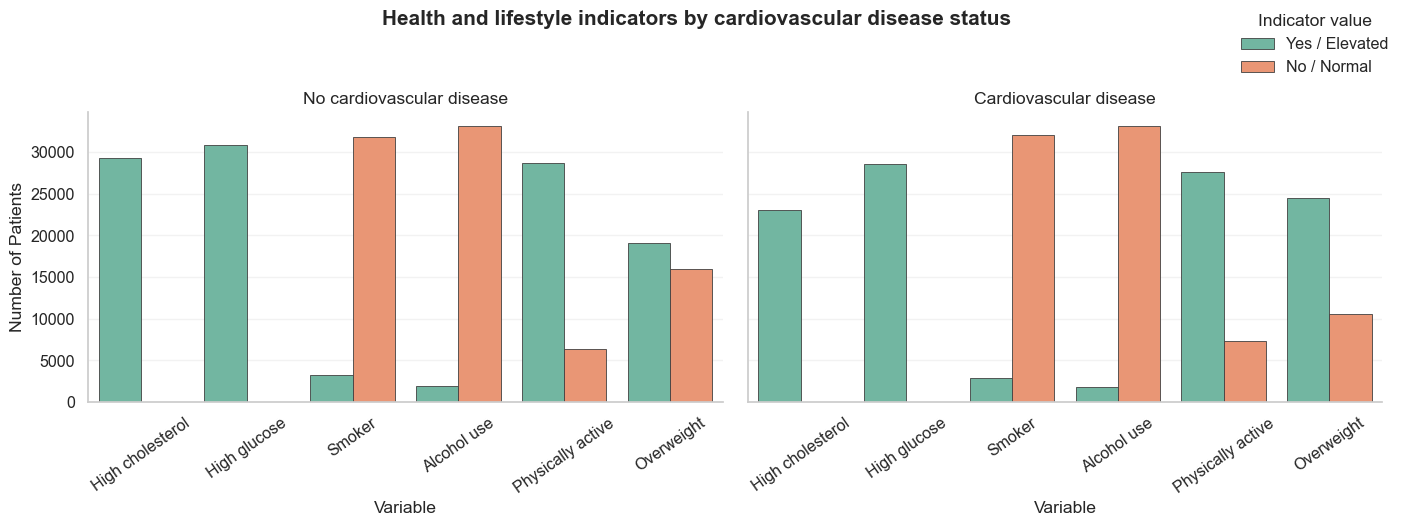

In [ ]:
def draw_cat_plot(df):

    """
        Compare lifestyle and health-risk indicators across patients with and without
        cardiovascular disease.

        Parameters
        ----------
        df:
            Cleaned medical exam dataframe containing binary risk indicators and cardio status.

        Returns
        -------
            Categorical plot grouped by cardiovascular disease status.
    """

    risk_features = ['cholesterol', 'gluc', 'smoke', 'alco', 'active', 'overweight']

    # Convert from wide to long format, which is the preferred structure for seaborn

    df_cat = pd.melt(df, id_vars=['cardio'], value_vars=risk_features, var_name="risk_factor")

    # Give variables and binary values reader-friendly labels

    df_cat["cardio"] = df_cat["cardio"].map({
        0: "No cardiovascular disease",
        1: "Cardiovascular disease",
    })
    df_cat["value"] = df_cat["value"].map({0: "No / Normal", 1: "Yes / Elevated"})
    df_cat["risk_factor"] = df_cat["risk_factor"].map({
        "cholesterol": "High cholesterol",
        "gluc": "High glucose",
        "smoke": "Smoker",
        "alco": "Alcohol use",
        "active": "Physically active",
        "overweight": "Overweight",
    })
    
    # Create figure

    fig = sns.catplot(data=df_cat, x="risk_factor", col='cardio', hue='value', 
                      kind="count", height=5, aspect=1.25, palette="Set2", 
                      edgecolor="0.25", linewidth=0.6,legend_out=True)
    fig.set_axis_labels('Variable', 'Number of Patients')
    fig.set_titles("{col_name}")

    fig.fig.suptitle(
        "Health and lifestyle indicators by cardiovascular disease status", y=1.05,
        fontsize=15, fontweight="bold")

    for ax in fig.axes.flat:
        ax.tick_params(axis="x", rotation=35)
        ax.grid(axis="y", alpha=0.25)
        ax.grid(axis="x", visible=False)
        ax.set_ylim(bottom=0)

    if fig._legend is not None:
        fig._legend.set_title("Indicator value")
        sns.move_legend(fig, 'upper right')

    fig.fig.tight_layout()

    return fig

draw_cat_plot(df)

### 3. Summary statistics

Support visual findings with tabulated summary statistics.

In [ ]:
# Basic summary statistics to support visual insights

summary = (
    df.groupby("cardio")
    [["cholesterol", "gluc", "smoke", "alco", "active", "overweight"]]
    .mean()
    .rename(index={0: "No cardiovascular disease", 1: "Cardiovascular disease"})
    .mul(100)
    .round(1)
)

summary

,cholesterol,gluc,smoke,alco,active,overweight
cardio,,,,,,
No cardiovascular disease,121.7,117.5,9.3,5.5,81.8,54.6
Cardiovascular disease,151.7,127.8,8.4,5.2,79.0,69.9


### 4. Findings from categorical plot

Generally, cholesterol levels, glucose levels, and whether a patient is overweight show moderate correlation with cardiovascular disease presence in patients. Smoking, alcohol, and whether a patient is active or not have minimal to no correlation with cardiovascular disease presence in patients based on this data. Of course, this does not indicate causation by any of these factors.

### 5. Heatmap

A heatmap is used to visualize correlation between risk features and outcomes from the dataset. 

First, outliers and patients with implausible medical results are removed, followed by heatmap generation using seaborn.

<Axes: title={'center': 'Correlation matrix after cleaning medical exam data'}>

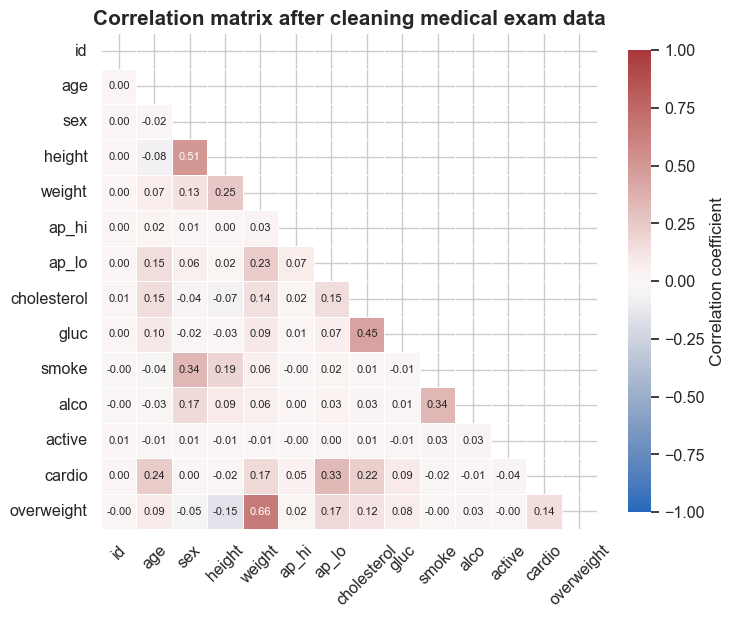

In [ ]:
# Import required packages

import numpy as np
import matplotlib.pyplot as plt

def draw_heat_map(df):

    """
    Plot correlations after filtering implausible blood-pressure values and
    extreme height/weight outliers.

    Parameters
    ----------
    df:
        Cleaned medical exam dataframe.

    Returns
    -------
        Heatmap plot
    """

    # Remove records that are likely data-entry errors or extreme outliers

    df_heat = df[(df['ap_lo'] <= df['ap_hi']) &
             (df['height'] >= df['height'].quantile(0.025)) &
             (df['height'] <= df['height'].quantile(0.975)) &
             (df['weight'] >= df['weight'].quantile(0.025)) &
             (df['weight'] <= df['weight'].quantile(0.975))]
    
    corr = df_heat.corr()

    # A lower-triangle mask is common for correlation matrices because the upper
    # triangle duplicates the same information.

    mask = np.zeros_like(corr)
    mask[np.triu_indices_from(mask)] = True

    # Create plot

    fig, ax = plt.subplots(figsize = (8, 8))

    sns.heatmap(corr, mask=mask, cmap="vlag", center=0, vmin=-1, vmax=1, annot=True,
        fmt=".2f", annot_kws={"size": 8}, square=True, linewidths=0.4,
        linecolor="white", cbar_kws={"shrink": 0.75, "label": "Correlation coefficient"},
        ax=ax)
    
    ax.set_title(
        "Correlation matrix after cleaning medical exam data",
        fontsize=15, fontweight="bold")
    
    ax.tick_params(axis="x", rotation=45)

    return ax

draw_heat_map(df)

### 6. Findings from heatmap

After removing outliers and potentially problematic patient data, it appears that no feature is very strongly correlated with the presence of cardiovascular disease, but systolic blood pressure, cholesterol levels, age, and weight have the greatest correlation (ranging from 0.17 to 0.33). It is difficult to comment on the exact reasons for these factors having the largest effects on cardiovascular disease presence without a proficient background in medicine and health (and even then it might be difficult or even impossible). However, all of these factors could sensibly have some effect on cardiovascular health (i.e., they are all related to health and/or physical attributes of patients), so it makes sense that some factors are notably correlated with cardiovascular health. 

Weight and overweight status have noticeable correlation, as expected. A heavier person generally means a higher likelihood that the person is overweight, and vice versa.

### 7. Comparison of findings

From the categorical plot, cholesterol levels, glucose levels, and whether a patient is overweight or not correlate most strongly with cardiovascular health, whereas the factors that correlate most from the heatmap are cholesterol levels, age, systolic blood pressure, and weight. 

The categorical plot neglects any factors that do not categorize patients into two different categories based on risk level, so systolic blood pressure, age, and weight do not show up on this plot. For this reason, as well as the removal of implausible and outlying data, the heatmap provides a more significant and complete description of factors correlated with cardiovascular health. Neglect of many features for the categorical plot also likely contributes to the discrepancy between feature importances from the categorical plot and the heatmap. Another factor could be removal of implausible and outlying data for the heatmap, which was not done for the categorical plot.